In [1]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import torch
from torch import nn
from torch.profiler import profiler
from torch.utils.benchmark import Timer, Compare
import torch_fftconv
import matplotlib.pyplot as plt

# Regular Convolution
## Varying input size

[---------------------- Conv2d ---------------------]
                       |  naive conv2d  |  fft conv2d
4 threads: ------------------------------------------
      input size: 64   |      3437.3    |     564.3  
      input size: 128  |     26231.8    |    1918.0  
      input size: 256  |    138062.3    |   14126.6  
      input size: 512  |    633503.0    |   76435.7  

Times are in microseconds (us).



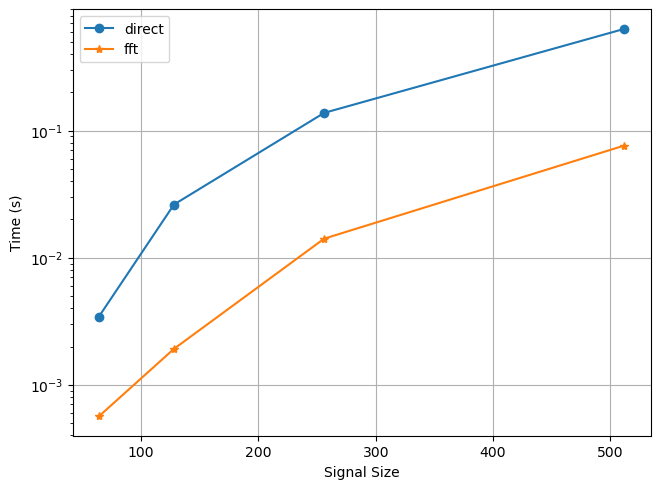

In [3]:
batch = 8
in_channels = 4
out_channels = 4
groups = 1
input_size = [64, 128, 256, 512]
kernel_size = 31
stride = 1
dilation = 1

model1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)
model2 = torch_fftconv.FFTConv2d(in_channels, out_channels, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)

results = []
for i_size in input_size:
    label = 'Conv2d'
    sub_label = f'input size: {i_size}'
    x = torch.ones(batch, in_channels, i_size, i_size)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(input_size, naive_result, marker='o', label='direct')
plt.plot(input_size, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Signal Size')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying kernel size

[---------------------- Conv2d ----------------------]
                        |  naive conv2d  |  fft conv2d
4 threads: -------------------------------------------
      kernel size: 15   |      37.9      |     12.4   
      kernel size: 31   |     140.5      |     13.8   
      kernel size: 63   |     417.3      |     13.3   
      kernel size: 127  |     779.1      |     13.2   

Times are in milliseconds (ms).



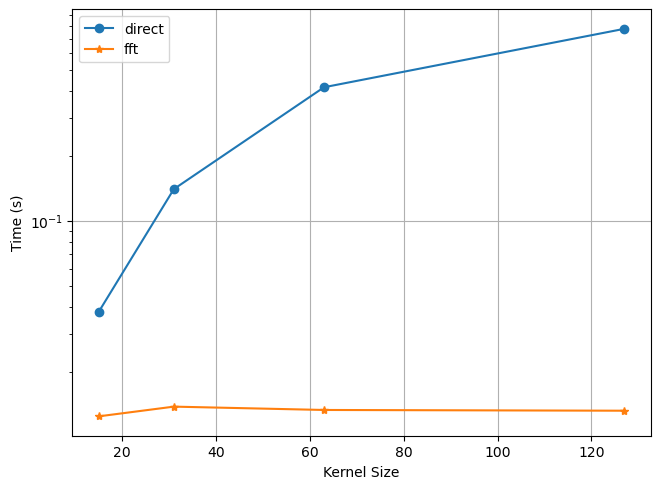

In [4]:
batch = 8
in_channels = 4
out_channels = 4
groups = 1
input_size = 256
kernel_size = [15, 31, 63, 127]
stride = 1
dilation = 1

x = torch.ones(batch, in_channels, input_size, input_size)

results = []
for k_size in kernel_size:
    label = 'Conv2d'
    sub_label = f'kernel size: {k_size}'

    model1 = nn.Conv2d(in_channels, out_channels, k_size, stride=stride, dilation=dilation, groups=groups, bias=False)
    model2 = torch_fftconv.FFTConv2d(in_channels, out_channels, k_size, stride=stride, dilation=dilation, groups=groups, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(kernel_size, naive_result, marker='o', label='direct')
plt.plot(kernel_size, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Kernel Size')
plt.ylabel('Time (s)')
plt.grid()
plt.savefig("images/benchmark_kernel.png", bbox_inches='tight', dpi=100)
#plt.show()

## Varying channel size

[---------------------- Conv2d ----------------------]
                        |  naive conv2d  |  fft conv2d
4 threads: -------------------------------------------
      channel size: 1   |      6954.7    |      340.5 
      channel size: 4   |     26531.2    |     2099.5 
      channel size: 16  |    131380.0    |    33125.8 
      channel size: 32  |    411356.6    |   168959.4 

Times are in microseconds (us).



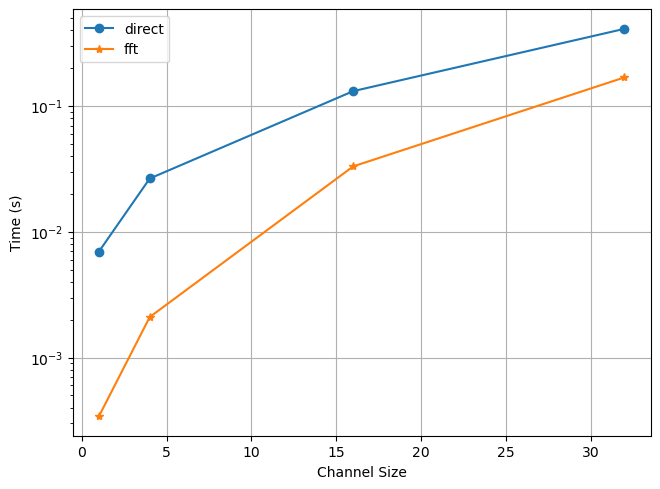

In [5]:
batch = 8
channels = [1, 4, 16, 32]
groups = 1
input_size = 128
kernel_size = 31
stride = 1
dilation = 1


results = []
for chs in channels:
    label = 'Conv2d'
    sub_label = f'channel size: {chs}'
    
    x = torch.ones(batch, chs, input_size, input_size)
    model1 = nn.Conv2d(chs, chs, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)
    model2 = torch_fftconv.FFTConv2d(chs, chs, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(channels, naive_result, marker='o', label='direct')
plt.plot(channels, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Channel Size')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying groups

[------------------- Conv2d ------------------]
                 |  naive conv2d  |  fft conv2d
4 threads: ------------------------------------
      groups: 1  |     394.1      |    172.2   
      groups: 2  |     261.2      |     72.9   
      groups: 4  |     207.4      |     36.7   
      groups: 8  |     435.2      |     16.9   

Times are in milliseconds (ms).



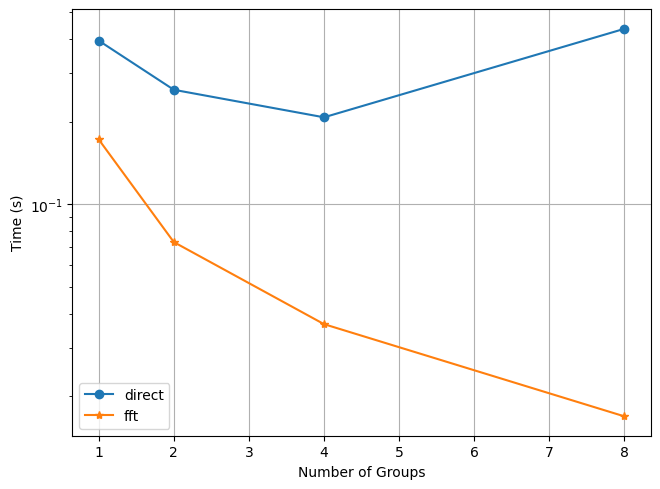

In [6]:
batch = 8
channels = 32
groups = [1, 2, 4, 8]
input_size = 128
kernel_size = 31
stride = 1
dilation = 1

x = torch.ones(batch, channels, input_size, input_size)

results = []
for g in groups:
    label = 'Conv2d'
    sub_label = f'groups: {g}'
    
    model1 = nn.Conv2d(channels, channels, kernel_size, stride=stride, dilation=dilation, groups=g, bias=False)
    model2 = torch_fftconv.FFTConv2d(channels, channels, kernel_size, stride=stride, dilation=dilation, groups=g, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(groups, naive_result, marker='o', label='direct')
plt.plot(groups, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Number of Groups')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying stride

[------------------- Conv2d ------------------]
                 |  naive conv2d  |  fft conv2d
4 threads: ------------------------------------
      stride: 1  |     618.0      |     77.6   
      stride: 2  |     157.7      |     66.6   
      stride: 3  |      70.4      |     81.1   
      stride: 5  |      26.5      |     75.4   
      stride: 7  |      13.4      |     73.8   

Times are in milliseconds (ms).



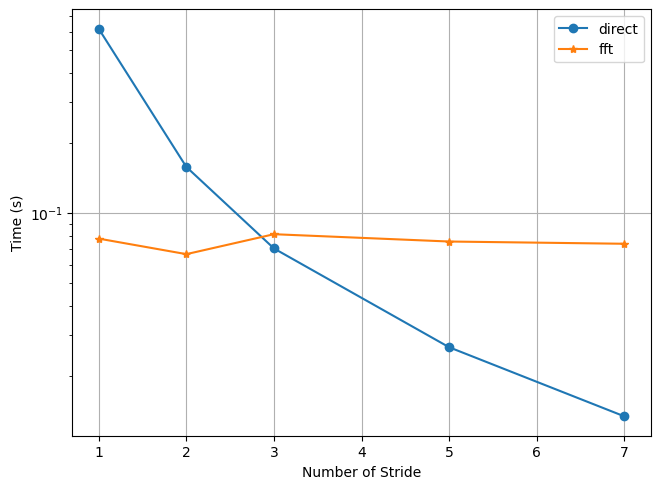

In [7]:
batch = 8
channels = 4
groups = 1
input_size = 512
kernel_size = 31
stride = [1, 2, 3, 5, 7]
dilation = 1

x = torch.ones(batch, channels, input_size, input_size)

results = []
for s in stride:
    label = 'Conv2d'
    sub_label = f'stride: {s}'
    
    model1 = nn.Conv2d(channels, channels, kernel_size, stride=s, dilation=dilation, groups=groups, bias=False)
    model2 = torch_fftconv.FFTConv2d(channels, channels, kernel_size, stride=s, dilation=dilation, groups=groups, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(stride, naive_result, marker='o', label='direct')
plt.plot(stride, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Number of Stride')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying dilation

[-------------------- Conv2d -------------------]
                   |  naive conv2d  |  fft conv2d
4 threads: --------------------------------------
      dilation: 1  |     620.3      |     76.7   
      dilation: 2  |     546.2      |     46.9   
      dilation: 3  |     476.0      |     78.6   
      dilation: 5  |     352.9      |     75.0   
      dilation: 7  |     248.4      |     86.1   

Times are in milliseconds (ms).



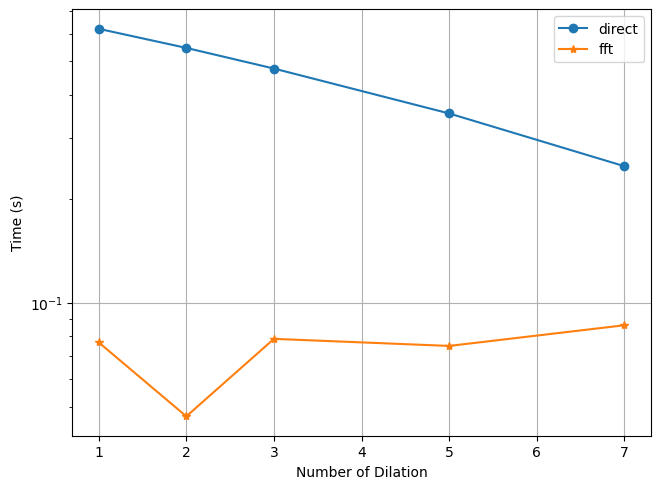

In [8]:
batch = 8
channels = 4
groups = 1
input_size = 512
kernel_size = 31
stride = 1
dilation = [1, 2, 3, 5, 7]

x = torch.ones(batch, channels, input_size, input_size)

results = []
for d in dilation:
    label = 'Conv2d'
    sub_label = f'dilation: {d}'
    
    model1 = nn.Conv2d(channels, channels, kernel_size, stride=stride, dilation=d, groups=groups, bias=False)
    model2 = torch_fftconv.FFTConv2d(channels, channels, kernel_size, stride=stride, dilation=d, groups=groups, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(dilation, naive_result, marker='o', label='direct')
plt.plot(dilation, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Number of Dilation')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

# Transpose Convolution
## Varying input size

[---------------------- Conv2d ---------------------]
                       |  naive conv2d  |  fft conv2d
4 threads: ------------------------------------------
      input size: 32   |       8.7      |      1.1   
      input size: 64   |      61.3      |      3.2   
      input size: 128  |     241.6      |      6.4   
      input size: 256  |     922.3      |     14.3   

Times are in milliseconds (ms).



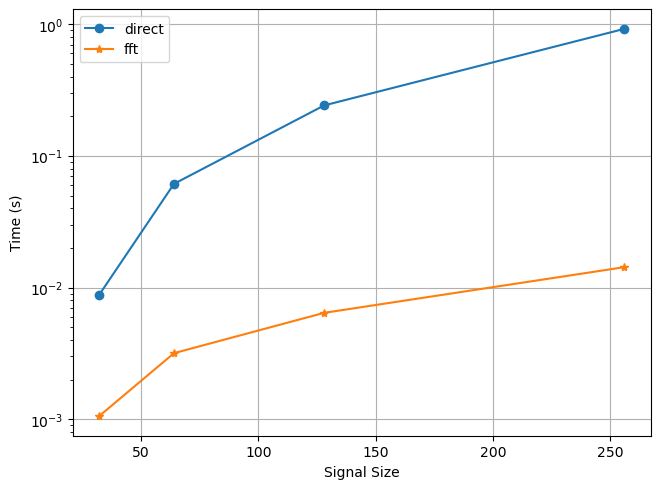

In [9]:
batch = 8
in_channels = 4
out_channels = 4
groups = 1
input_size = [32, 64, 128, 256]
kernel_size = 31
stride = 1
dilation = 1

model1 = nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)
model2 = torch_fftconv.FFTConvTranspose2d(in_channels, out_channels, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)

results = []
for i_size in input_size:
    label = 'Conv2d'
    sub_label = f'input size: {i_size}'
    x = torch.ones(batch, in_channels, i_size, i_size)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(input_size, naive_result, marker='o', label='direct')
plt.plot(input_size, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Signal Size')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying kernel size

[---------------------- Conv2d ---------------------]
                       |  naive conv2d  |  fft conv2d
4 threads: ------------------------------------------
      kernel size: 7   |       3.4      |     5.1    
      kernel size: 15  |      61.1      |     5.1    
      kernel size: 31  |     240.6      |     6.5    
      kernel size: 63  |     667.7      |     8.2    

Times are in milliseconds (ms).



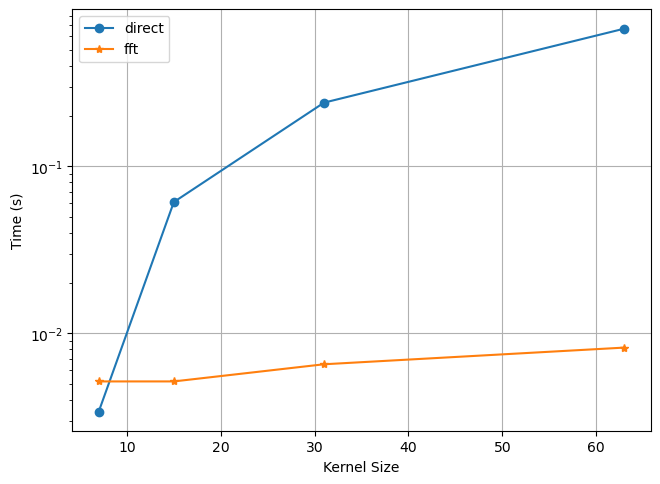

In [10]:
batch = 8
in_channels = 4
out_channels = 4
groups = 1
input_size = 128
kernel_size = [7, 15, 31, 63]
stride = 1
dilation = 1

x = torch.ones(batch, in_channels, input_size, input_size)

results = []
for k_size in kernel_size:
    label = 'Conv2d'
    sub_label = f'kernel size: {k_size}'

    model1 = nn.ConvTranspose2d(in_channels, out_channels, k_size, stride=stride, dilation=dilation, groups=groups, bias=False)
    model2 = torch_fftconv.FFTConvTranspose2d(in_channels, out_channels, k_size, stride=stride, dilation=dilation, groups=groups, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(kernel_size, naive_result, marker='o', label='direct')
plt.plot(kernel_size, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Kernel Size')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying channel size

[---------------------- Conv2d ----------------------]
                        |  naive conv2d  |  fft conv2d
4 threads: -------------------------------------------
      channel size: 1   |      7339.2    |     277.9  
      channel size: 4   |     12929.6    |     804.6  
      channel size: 16  |     60064.1    |   12667.7  
      channel size: 32  |    136115.8    |   42266.8  

Times are in microseconds (us).



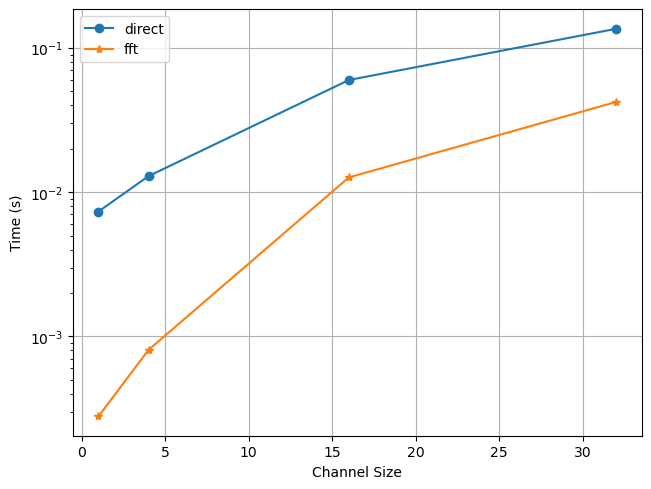

In [11]:
batch = 8
channels = [1, 4, 16, 32]
groups = 1
input_size = 64
kernel_size = 15
stride = 1
dilation = 1


results = []
for chs in channels:
    label = 'Conv2d'
    sub_label = f'channel size: {chs}'
    
    x = torch.ones(batch, chs, input_size, input_size)
    model1 = nn.ConvTranspose2d(chs, chs, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)
    model2 = torch_fftconv.FFTConvTranspose2d(chs, chs, kernel_size, stride=stride, dilation=dilation, groups=groups, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(channels, naive_result, marker='o', label='direct')
plt.plot(channels, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Channel Size')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying groups

[------------------- Conv2d ------------------]
                 |  naive conv2d  |  fft conv2d
4 threads: ------------------------------------
      groups: 1  |     132.2      |     40.6   
      groups: 2  |     107.9      |     21.0   
      groups: 4  |     100.3      |     12.4   
      groups: 8  |      78.4      |      6.5   

Times are in milliseconds (ms).



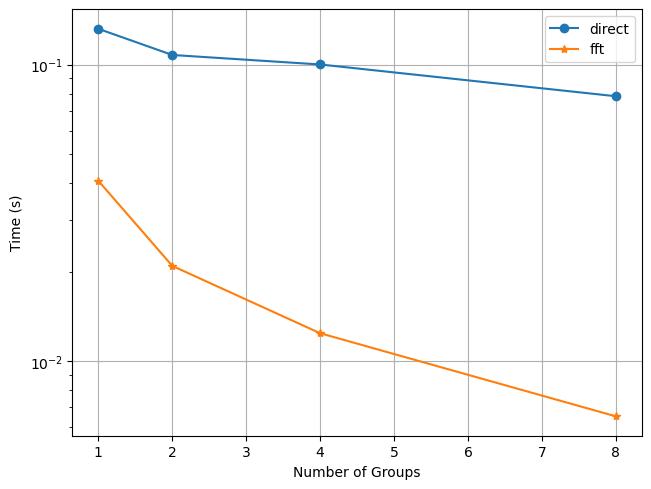

In [12]:
batch = 8
channels = 32
groups = [1, 2, 4, 8]
input_size = 64
kernel_size = 15
stride = 1
dilation = 1

x = torch.ones(batch, channels, input_size, input_size)

results = []
for g in groups:
    label = 'Conv2d'
    sub_label = f'groups: {g}'
    
    model1 = nn.ConvTranspose2d(channels, channels, kernel_size, stride=stride, dilation=dilation, groups=g, bias=False)
    model2 = torch_fftconv.FFTConvTranspose2d(channels, channels, kernel_size, stride=stride, dilation=dilation, groups=g, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(groups, naive_result, marker='o', label='direct')
plt.plot(groups, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Number of Groups')
plt.ylabel('Time (s)')
plt.grid()
plt.show()

## Varying stride

[------------------- Conv2d ------------------]
                 |  naive conv2d  |  fft conv2d
4 threads: ------------------------------------
      stride: 1  |      53.3      |      6.0   
      stride: 2  |       7.2      |     13.7   
      stride: 3  |      13.6      |     32.1   
      stride: 5  |      32.0      |    111.1   
      stride: 7  |      47.7      |    251.7   

Times are in milliseconds (ms).



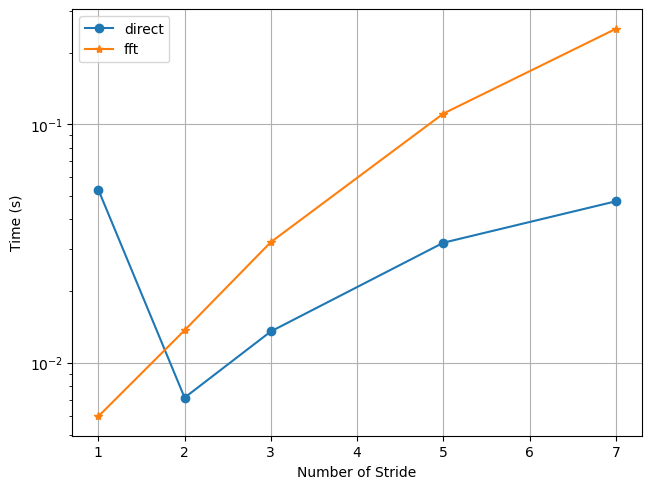

In [13]:
batch = 8
channels = 4
groups = 1
input_size = 128
kernel_size = 15
stride = [1, 2, 3, 5, 7]
dilation = 1

x = torch.ones(batch, channels, input_size, input_size)

results = []
for s in stride:
    label = "Conv2d"
    sub_label = f"stride: {s}"

    model1 = nn.ConvTranspose2d(
        channels,
        channels,
        kernel_size,
        stride=s,
        dilation=dilation,
        groups=groups,
        bias=False,
    )
    model2 = torch_fftconv.FFTConvTranspose2d(
        channels,
        channels,
        kernel_size,
        stride=s,
        dilation=dilation,
        groups=groups,
        bias=False,
    )
    model1.compile(dynamic=True)
    model2.compile(dynamic=True)

    results.append(
        Timer(
            stmt="m(x)",
            setup="",
            globals={"x": x, "m": model1},
            num_threads=4,
            label=label,
            sub_label=sub_label,
            description="naive conv2d",
        ).blocked_autorange(min_run_time=1)
    )
    results.append(
        Timer(
            stmt="m(x)",
            setup="",
            globals={"x": x, "m": model2},
            num_threads=4,
            label=label,
            sub_label=sub_label,
            description="fft conv2d",
        ).blocked_autorange(min_run_time=1)
    )

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(stride, naive_result, marker="o", label="direct")
plt.plot(stride, fft_result, marker="*", label="fft")
plt.tight_layout()
plt.yscale("log")
plt.legend()
plt.xlabel("Number of Stride")
plt.ylabel("Time (s)")
plt.grid()
plt.show()

## Varying dilation

[-------------------- Conv2d -------------------]
                   |  naive conv2d  |  fft conv2d
4 threads: --------------------------------------
      dilation: 1  |     242.1      |      6.6   
      dilation: 2  |     230.4      |      9.1   
      dilation: 3  |     219.5      |     10.4   
      dilation: 5  |     237.0      |     11.3   
      dilation: 7  |     224.4      |     23.2   

Times are in milliseconds (ms).



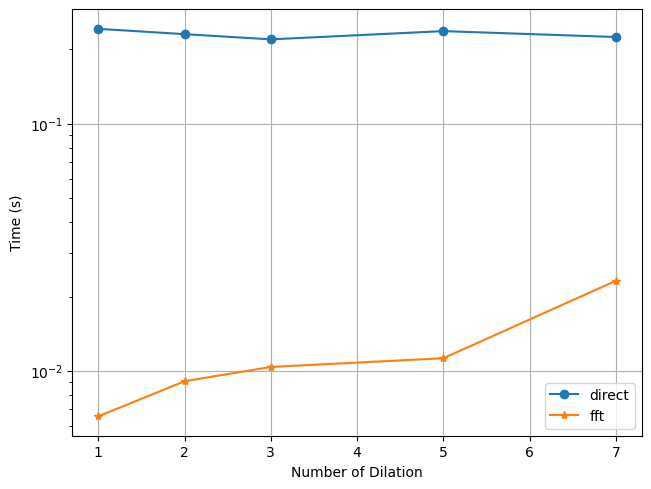

In [14]:
batch = 8
channels = 4
groups = 1
input_size = 128
kernel_size = 31
stride = 1
dilation = [1, 2, 3, 5, 7]

x = torch.ones(batch, channels, input_size, input_size)

results = []
for d in dilation:
    label = 'Conv2d'
    sub_label = f'dilation: {d}'
    
    model1 = nn.ConvTranspose2d(channels, channels, kernel_size, stride=stride, dilation=d, groups=groups, bias=False)
    model2 = torch_fftconv.FFTConvTranspose2d(channels, channels, kernel_size, stride=stride, dilation=d, groups=groups, bias=False)

    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model1},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='naive conv2d',
    ).blocked_autorange(min_run_time=1))
    results.append(Timer(
        stmt='m(x)',
        setup='',
        globals={'x': x, 'm': model2},
        num_threads=4,
        label=label,
        sub_label=sub_label,
        description='fft conv2d',
    ).blocked_autorange(min_run_time=1))

compare = Compare(results)
compare.print()

naive_result = [x.median for x in results[::2]]
fft_result = [x.median for x in results[1::2]]

plt.plot(dilation, naive_result, marker='o', label='direct')
plt.plot(dilation, fft_result, marker='*', label='fft')
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.xlabel('Number of Dilation')
plt.ylabel('Time (s)')
plt.grid()
plt.show()